In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys, os
sys.path.append(os.path.abspath("../src"))

from black_scholes_merton import price_option_bsm
from binomial_model import price_option_tree
from implied_vol import implied_vol_brent

In [14]:
s = 100
k = 50
T = 1
r = 0.1
sigma_vals = np.linspace(0.03, 1, 20)
implied_vol_vals = np.zeros_like(sigma_vals)
q = 0.02
option_type = 'call'
exercise_style = 'European'

for i, sigma in enumerate(sigma_vals):
    
    price_bsm = price_option_bsm(option_type, exercise_style, s, k, r, sigma, T, q)

    implied_vol_vals[i] = implied_vol_brent(option_type, exercise_style, price_bsm, s, k, r, T, q, sigma_low=1e-2, sigma_high=1)

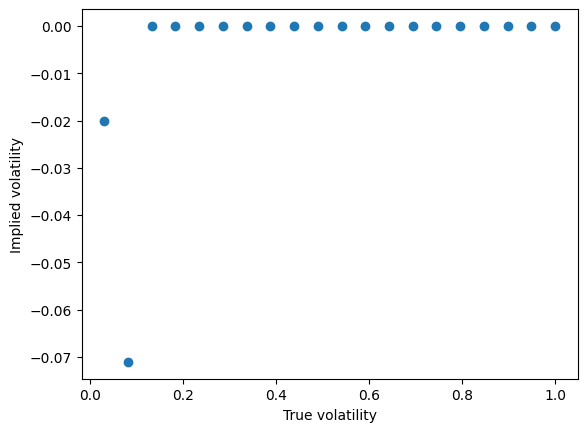

In [15]:
plt.scatter(sigma_vals, implied_vol_vals - sigma_vals)
plt.xlabel('True volatility')
plt.ylabel('Implied volatility')
plt.show()

In [16]:
print(price_option_bsm(option_type, exercise_style, s, k, r, 0.1, T, q))
print(price_option_bsm(option_type, exercise_style, s, k, r, 1e-4, T, q))

52.77799642887755
52.77799642887755


In [11]:
s = 50
k = 50
T = 1
r = 0.1
sigma_vals = np.linspace(0.03, 1, 20)
implied_vol_vals_N4 = np.zeros_like(sigma_vals)
implied_vol_vals_N20 = np.zeros_like(sigma_vals)
q = 0.02
N=100
option_type = 'put'
exercise_style = 'American'

for i, sigma in enumerate(sigma_vals):
    print(i)
    price_tree = price_option_tree(option_type, exercise_style, s, k, r, sigma, T, N=N, q=q)
    implied_vol_vals[i] = implied_vol_brent(option_type, exercise_style, price_tree, s, k, r, T, q, sigma_low=1e-2, sigma_high=2, N=N)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


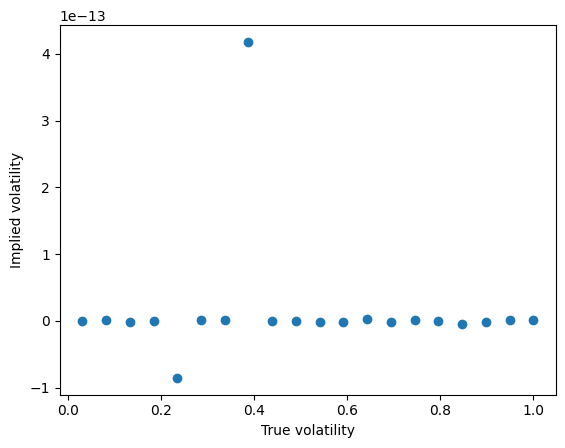

In [12]:
plt.scatter(sigma_vals, implied_vol_vals - sigma_vals)
plt.xlabel('True volatility')
plt.ylabel('Implied volatility')
plt.show()

In [13]:
print(sigma_vals, implied_vol_vals)

[0.03       0.08105263 0.13210526 0.18315789 0.23421053 0.28526316
 0.33631579 0.38736842 0.43842105 0.48947368 0.54052632 0.59157895
 0.64263158 0.69368421 0.74473684 0.79578947 0.84684211 0.89789474
 0.94894737 1.        ] [0.03       0.08105263 0.13210526 0.18315789 0.23421053 0.28526316
 0.33631579 0.38736842 0.43842105 0.48947368 0.54052632 0.59157895
 0.64263158 0.69368421 0.74473684 0.79578947 0.84684211 0.89789474
 0.94894737 1.        ]
